# Seattle weather — quick look

Just poking at some hourly temperature data for SeaTac.
Want to see the seasonal + daily pattern and try a naive next-day forecast.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [2]:
# generate a year of hourly data for SeaTac
# (in a real analysis this would be a CSV from NOAA, but this makes the
# notebook self-contained for the demo)

np.random.seed(42)

hours = pd.date_range('2024-01-01 00:00', '2024-12-31 23:00', freq='h', tz='UTC')

# seasonal signal: cold in Jan/Feb, warm in Jul/Aug
doy = hours.dayofyear.to_numpy()
seasonal = 9 + 11 * np.sin(2 * np.pi * (doy - 100) / 365.25)

# diurnal signal: peak at ~22:00 UTC = ~15:00 PST (3 PM, the realistic afternoon peak)
hod = hours.hour.to_numpy()
diurnal = 5 * np.sin(2 * np.pi * (hod - 16) / 24)

# noise
noise = np.random.normal(0, 1.8, len(hours))

temp = seasonal + diurnal + noise

df = pd.DataFrame({
    'timestamp': hours.tz_localize(None),  # strip tz — data files usually don't carry it
    'temp_c': temp,
})

df.to_csv('ksea_2024.csv', index=False)
print(f'wrote {len(df)} rows')

wrote 8784 rows


## Load the data

In [3]:
df = pd.read_csv('ksea_2024.csv')
df.head()

,timestamp,temp_c
0,2024-01-01 00:00:00,3.320258
1,2024-01-01 01:00:00,1.382704
2,2024-01-01 02:00:00,1.761885
3,2024-01-01 03:00:00,2.131595
4,2024-01-01 04:00:00,-2.325430


In [4]:
df.describe()

,temp_c
count,8784.000000
mean,8.977433
std,8.687580
min,-10.649596
25%,2.008645
50%,8.971819
75%,16.018407
max,30.316773


## Clean up

Convert the timestamp column and set as index.

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp')
df.head()

,temp_c
timestamp,
2024-01-01 00:00:00,3.320258
2024-01-01 01:00:00,1.382704
2024-01-01 02:00:00,1.761885
2024-01-01 03:00:00,2.131595
2024-01-01 04:00:00,-2.325430


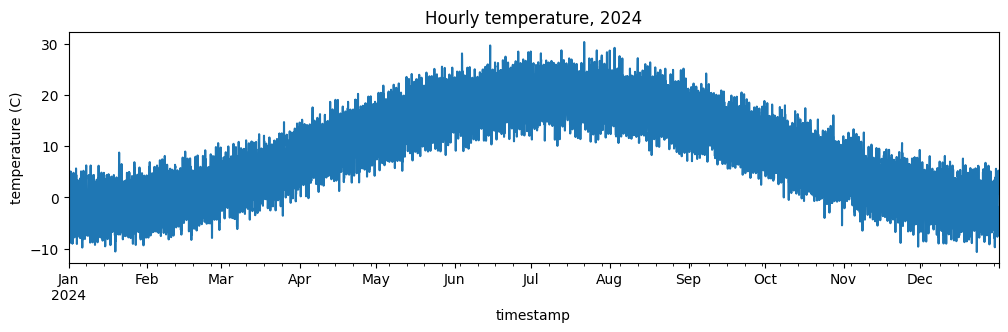

In [6]:
df['temp_c'].plot(figsize=(12, 3))
plt.ylabel('temperature (C)')
plt.title('Hourly temperature, 2024')
plt.show()

## Daily aggregation

Get daily mean/min/max.

In [7]:
daily = df['temp_c'].resample('D').agg(['mean', 'max', 'min'])
daily.head(10)

,mean,max,min
timestamp,,,
2024-01-01,-2.169703,5.064341,-8.883392
2024-01-02,-2.400612,4.805159,-8.990231
2024-01-03,-1.773105,5.650701,-7.788112
2024-01-04,-2.202902,4.387635,-9.077415
2024-01-05,-1.886971,5.079205,-7.931664
2024-01-06,-2.149644,5.194239,-9.779441
2024-01-07,-1.614268,6.248491,-8.110827
2024-01-08,-1.946371,4.371916,-7.475613
2024-01-09,-1.429538,6.229171,-8.809773


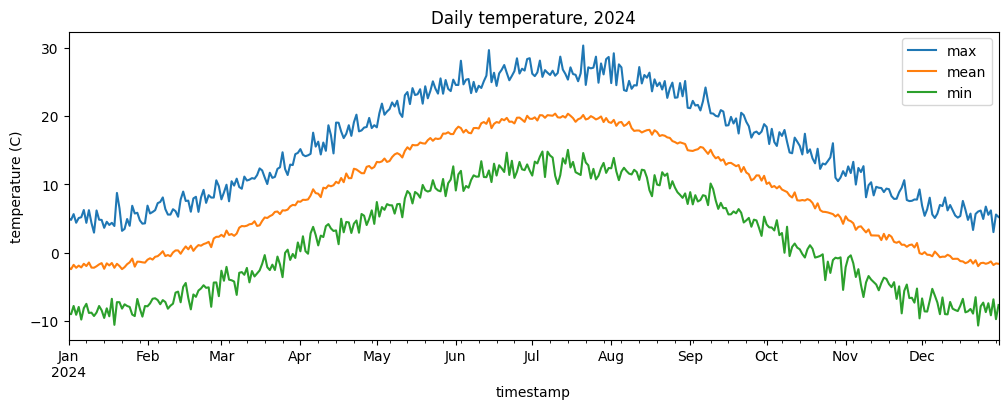

In [8]:
daily[['max', 'mean', 'min']].plot(figsize=(12, 4))
plt.ylabel('temperature (C)')
plt.title('Daily temperature, 2024')
plt.show()

## Diurnal pattern

What does a typical day look like?

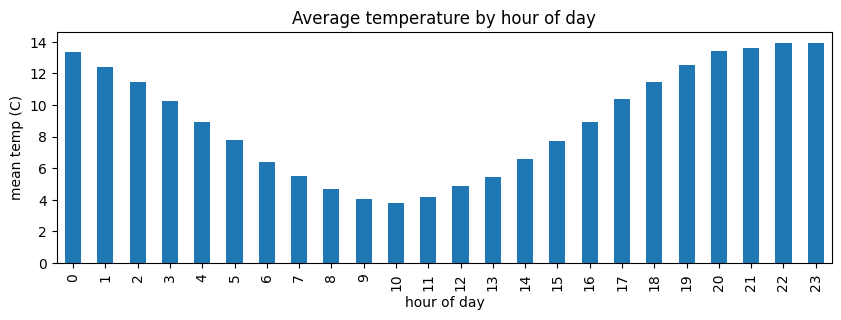

peak hour: 23
coldest hour: 10


In [9]:
df['hour'] = df.index.hour
by_hour = df.groupby('hour')['temp_c'].mean()
by_hour.plot(kind='bar', figsize=(10, 3))
plt.ylabel('mean temp (C)')
plt.xlabel('hour of day')
plt.title('Average temperature by hour of day')
plt.show()

print(f'peak hour: {by_hour.idxmax()}')
print(f'coldest hour: {by_hour.idxmin()}')

## Naive forecast

Predict tomorrow's max as the mean of the last 7 daily maxes.

In [10]:
last_7 = daily['max'].iloc[-7:]
forecast = last_7.mean()
print(f'last 7 daily maxes:')
print(last_7)
print(f'\nforecast for next day max: {forecast:.1f} C')

last 7 daily maxes:
timestamp
2024-12-25    4.939210
2024-12-26    6.752131
2024-12-27    5.545002
2024-12-28    6.191238
2024-12-29    3.017558
2024-12-30    5.590473
2024-12-31    5.232773
Freq: D, Name: max, dtype: float64

forecast for next day max: 5.3 C
